In [2]:
## 1. Import Libraries

import os
import zipfile
import hashlib

from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

In [3]:
## 2. Define local project paths

PROJECT_ROOT = Path.cwd().parent

zip_path = PROJECT_ROOT / "data" / "TBX11K.zip"
output_dir = PROJECT_ROOT / "outputs" / "eda"

# Create the EDA output folder
output_dir.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_ROOT)
print("ZIP path:", zip_path)
print("ZIP found:", zip_path.exists())
print("EDA output folder:", output_dir)
print("Output folder ready:", output_dir.exists())

Project folder: C:\Users\A\Desktop\msc data science thesis
ZIP path: C:\Users\A\Desktop\msc data science thesis\data\TBX11K.zip
ZIP found: True
EDA output folder: C:\Users\A\Desktop\msc data science thesis\outputs\eda
Output folder ready: True


In [5]:
## 3. Load the official training and validation file lists

with zipfile.ZipFile(zip_path, "r") as zip_file:
    train_files = zip_file.read("TBX11K/lists/TBX11K_train.txt").decode("utf-8").splitlines()

    val_files = zip_file.read("TBX11K/lists/TBX11K_val.txt").decode("utf-8").splitlines()

# Remove blank lines and extra spaces
train_files = [path.strip() for path in train_files if path.strip()]
val_files = [path.strip() for path in val_files if path.strip()]

print("Training images:", len(train_files))
print("Validation images:", len(val_files))
print("Total images:", len(train_files) + len(val_files))

Training images: 6600
Validation images: 1800
Total images: 8400


In [6]:
## 4. Create one metadata row for every selected image

records = []

for split, file_paths in {"train": train_files,"validation": val_files}.items():

    for path in file_paths:
        original_class = path.split("/")[0]

        binary_label = ("TB" if original_class == "tb" else "Non-TB")

        records.append({
            "path": path,
            "split": split,
            "original_class": original_class,
            "binary_label": binary_label
        })

eda_df = pd.DataFrame(records)

print("EDA table shape:", eda_df.shape)
display(eda_df.head())

EDA table shape: (8400, 4)


,path,split,original_class,binary_label
0,tb/tb0005.png,train,tb,TB
1,tb/tb0007.png,train,tb,TB
2,tb/tb0012.png,train,tb,TB
3,tb/tb0017.png,train,tb,TB
4,tb/tb0018.png,train,tb,TB


original_class,health,sick,tb
split,,,
train,3000,3000,600
validation,800,800,200


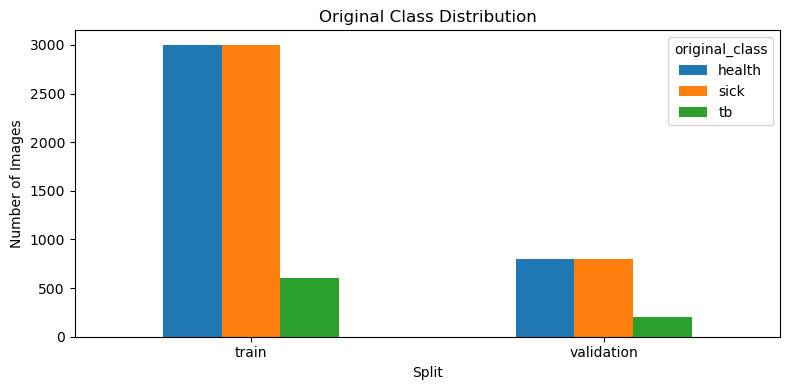

In [7]:
## 5. Original Class Distribution

# Count original classes in each split
original_counts = pd.crosstab( eda_df["split"], eda_df["original_class"])

display(original_counts)

# Plot original class counts
original_counts.plot( kind="bar", figsize=(8, 4))

plt.title("Original Class Distribution")
plt.xlabel("Split")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, "original_class_distribution.png"), dpi=300, bbox_inches="tight")

plt.show()

binary_label,Non-TB,TB
split,,
train,6000,600
validation,1600,200


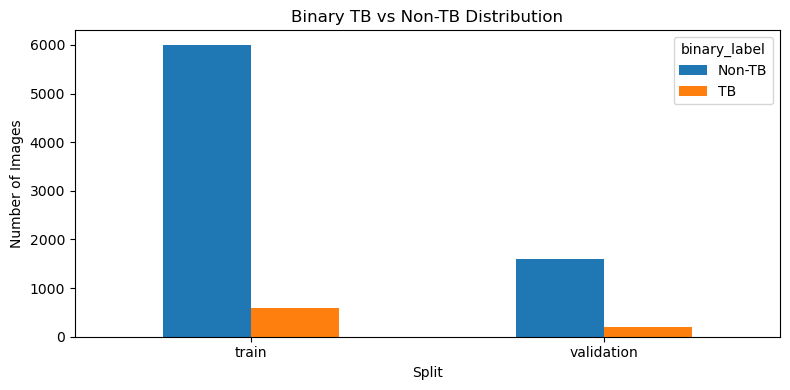

binary_label,Non-TB,TB
split,,
train,90.91,9.09
validation,88.89,11.11


In [8]:
## 6. Binary Class Distribution

# Count TB and Non-TB in each split
binary_counts = pd.crosstab(eda_df["split"], eda_df["binary_label"])

display(binary_counts)

# Plot binary class counts
binary_counts.plot(kind="bar",figsize=(8, 4))

plt.title("Binary TB vs Non-TB Distribution")
plt.xlabel("Split")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, "binary_class_distribution.png"), dpi=300, bbox_inches="tight")

plt.show()

binary_percentages = pd.crosstab(eda_df["split"], eda_df["binary_label"], normalize="index").mul(100).round(2)

display(binary_percentages)

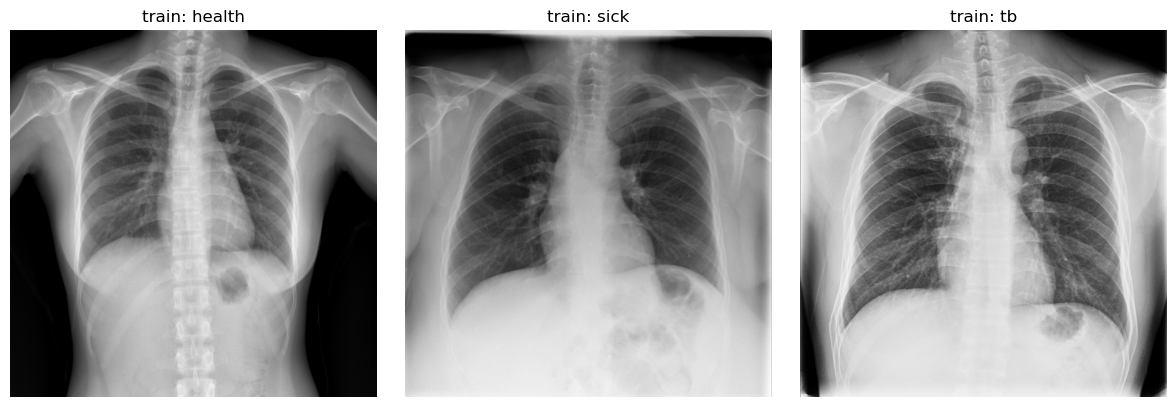

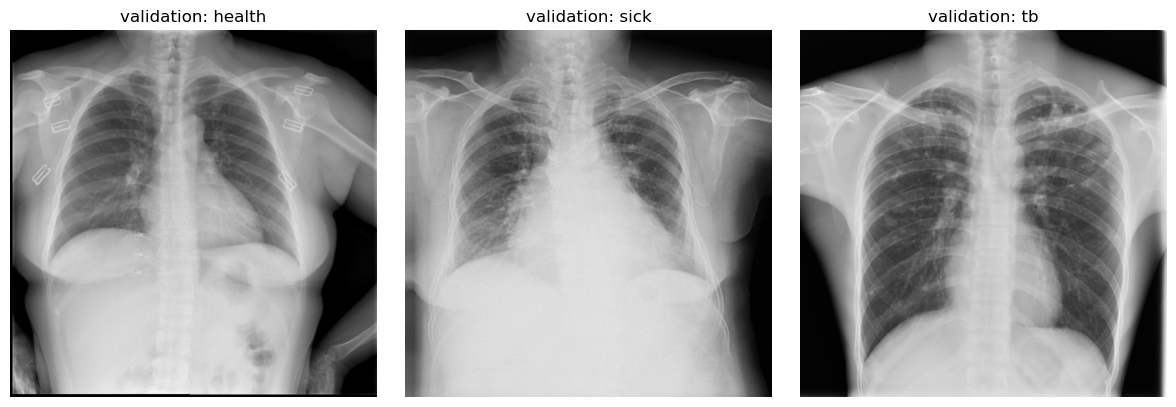

In [10]:
## 7. Visual Inspection of Sample Images

# Load one image from the ZIP
def load_rgb_image(path):

    full_path = f"TBX11K/imgs/{path}"

    with zipfile.ZipFile(zip_path, "r") as zip_file:
        image_bytes = zip_file.read(full_path)

    return Image.open(BytesIO(image_bytes)).convert("RGB")


# Show one image from each class side by side
def show_split_examples(split_name):

    classes = ["health", "sick", "tb"]

    # One row and three columns
    fig, axes = plt.subplots(1,3,figsize=(12, 4))

    for col, class_name in enumerate(classes):

        # Select one image from the class and split
        path = eda_df[
            (eda_df["split"] == split_name) &
            (eda_df["original_class"] == class_name)
        ].sample(1,random_state=42)["path"].iloc[0]

        # Display the image
        axes[col].imshow(load_rgb_image(path))

        axes[col].set_title(f"{split_name}: {class_name}")

        axes[col].axis("off")

    plt.tight_layout()

    plt.savefig(os.path.join(output_dir, f"sample_{split_name}_images.png"), dpi=300, bbox_inches="tight")

    plt.show()


# Display training examples
show_split_examples("train")

# Display validation examples
show_split_examples("validation")

In [11]:
## 8. Calculate Image-Level Statistics

# Store results for every image
channel_max_diffs = []
channel_identical = []
mean_intensities = []
std_intensities = []
pixel_hashes = []
border_center_diffs = []
corner_variations = []

# Areas used for border checks
border_width = 20
centre_margin = 64
corner_size = 64

# analysing images
with zipfile.ZipFile(zip_path, "r") as zip_file:

    for path in tqdm(eda_df["path"], desc="Analysing images"):

        # Read image from ZIP
        full_path = f"TBX11K/imgs/{path}"
        image_bytes = zip_file.read(full_path)
        image = Image.open(BytesIO(image_bytes)).convert("RGB")

        # Convert image to arrays
        rgb = np.asarray(image)
        gray = np.asarray(image.convert("L"), dtype=np.float32)

        # Check RGB-channel differences
        rgb_int = rgb.astype(np.int16)
        max_difference = int(np.ptp(rgb_int, axis=2).max())

        channel_max_diffs.append(max_difference)
        channel_identical.append(max_difference == 0)

        # Brightness and contrast
        mean_intensities.append(float(gray.mean()))
        std_intensities.append(float(gray.std()))

        # Create exact image fingerprint
        pixel_hashes.append(hashlib.sha256(rgb.tobytes()).hexdigest())

        # Select outer border pixels
        b = border_width

        border_pixels = np.concatenate([
            gray[:b, :].ravel(),
            gray[-b:, :].ravel(),
            gray[b:-b, :b].ravel(),
            gray[b:-b, -b:].ravel()
        ])

        # Select central image area
        m = centre_margin
        centre = gray[m:-m, m:-m]

        border_center_diffs.append(float(abs(border_pixels.mean() - centre.mean())))

        # Select four corners
        c = corner_size

        corners = [
            gray[:c, :c],
            gray[:c, -c:],
            gray[-c:, :c],
            gray[-c:, -c:]
        ]

        corner_variations.append(float(max(corner.std() for corner in corners)))

# Add calculated statistics
eda_df["channel_max_diff"] = channel_max_diffs
eda_df["channels_identical"] = channel_identical
eda_df["mean_intensity"] = mean_intensities
eda_df["std_intensity"] = std_intensities
eda_df["pixel_hash"] = pixel_hashes
eda_df["border_center_diff"] = border_center_diffs
eda_df["corner_variation"] = corner_variations

print("Table shape:", eda_df.shape)
display(eda_df.head())

# Save the complete EDA statistics table

eda_df.to_csv(
    os.path.join(output_dir, "eda_image_statistics.csv"),
    index=False
)

print("EDA statistics saved")
print("Rows saved:", len(eda_df))



Analysing images:   0%|          | 0/8400 [00:00<?, ?it/s]

Table shape: (8400, 11)


,path,split,original_class,binary_label,channel_max_diff,channels_identical,mean_intensity,std_intensity,pixel_hash,border_center_diff,corner_variation
0,tb/tb0005.png,train,tb,TB,0,True,146.426788,71.611267,206f531c511e2d861735005e6aa69706099aa929f57be2...,47.852768,85.053032
1,tb/tb0007.png,train,tb,TB,0,True,133.855209,78.007851,e157cc364238ece15c6539f692d62d062794608c09b1b5...,55.975677,55.898422
2,tb/tb0012.png,train,tb,TB,0,True,129.319397,72.573952,4458c6997d15f93e12f36403b83eb79ffd8930e0eafdd5...,104.776382,46.297451
3,tb/tb0017.png,train,tb,TB,0,True,130.021606,81.380669,79d624467d73aec9fbb7b7cdf975c3c7787f543b53a63e...,68.543480,90.311554
4,tb/tb0018.png,train,tb,TB,0,True,141.269806,74.255219,554a53780833366816f70cd557c138829a88ccf2e5ece5...,3.705475,97.077095


EDA statistics saved
Rows saved: 8400


In [12]:
## 9. Review RGB-Channel Content

# Count identical and non-identical RGB channels
print(eda_df["channels_identical"].value_counts())

# Find the largest RGB-channel difference
print("Largest channel difference:", eda_df["channel_max_diff"].max())

channels_identical
True    8400
Name: count, dtype: int64
Largest channel difference: 0


mean_intensity                std_intensity         \
                                    mean  median    std          mean median   
split      original_class                                                      
train      health                 120.58  122.60  19.33         65.11  65.51   
           sick                   147.76  151.17  17.31         62.63  62.80   
           tb                     132.08  134.23  15.80         69.75  69.75   
validation health                 121.51  124.01  19.56         65.15  65.66   
           sick                   149.06  151.64  16.82         62.28  62.89   
           tb                     131.21  133.05  15.88         69.99  69.88   

                                 
                            std  
split      original_class        
train      health          5.26  
           sick            6.88  
           tb              6.40  
validation health          5.20  
           sick            6.96  
           tb              6.48

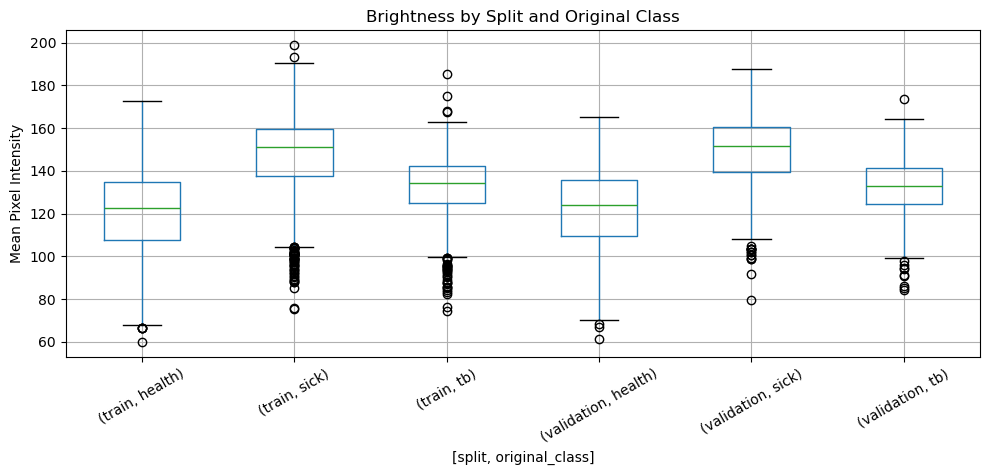

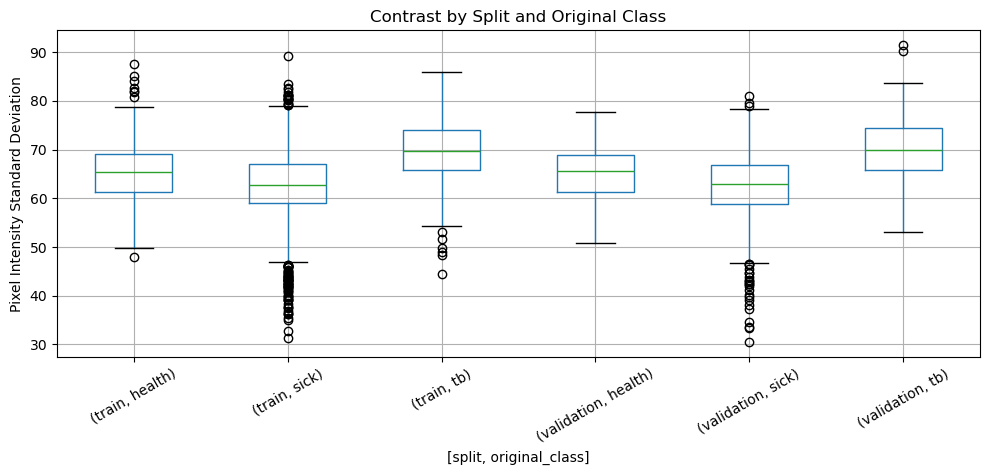

In [13]:
## 10. Brightness and Contrast Analysis

# Summarise brightness and contrast by split and class
summary = eda_df.groupby(["split", "original_class"])[["mean_intensity", "std_intensity"]].agg(["mean", "median", "std"]).round(2)

display(summary)

# Compare image brightness
eda_df.boxplot(column="mean_intensity", by=["split", "original_class"], figsize=(10, 5),rot=30)

plt.title("Brightness by Split and Original Class")
plt.suptitle("")
plt.ylabel("Mean Pixel Intensity")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "brightness_by_class.png"), dpi=300, bbox_inches="tight")
plt.show()

# Compare image contrast
eda_df.boxplot(column="std_intensity", by=["split", "original_class"], figsize=(10, 5), rot=30)

plt.title("Contrast by Split and Original Class")
plt.suptitle("")
plt.ylabel("Pixel Intensity Standard Deviation")
plt.tight_layout()

plt.savefig(os.path.join(output_dir, "contrast_by_class.png"),dpi=300, bbox_inches="tight")
plt.show()

border_center_diff         corner_variation        
                                      median     max           median     max
split      original_class                                                    
train      health                      62.92  103.51            48.31   98.55
           sick                        53.31  123.70            60.31  103.45
           tb                          51.43  126.93            67.88  103.94
validation health                      62.85  106.79            49.83   95.14
           sick                        53.24  108.22            59.87   94.43
           tb                          53.63  111.39            65.90  101.10

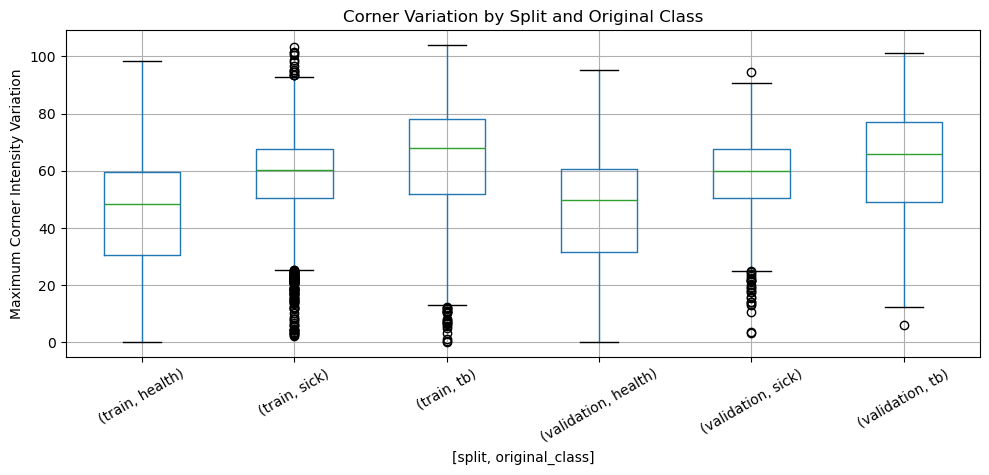

In [14]:
## 11. Border and Corner Artefact Analysis

# Summarise border and corner scores
artefact_summary = eda_df.groupby(["split", "original_class"])[["border_center_diff", "corner_variation"]].agg(["median", "max"]).round(2)

display(artefact_summary)

# Compare corner variation across groups
eda_df.boxplot(column="corner_variation",by=["split", "original_class"],figsize=(10, 5),rot=30)

plt.title("Corner Variation by Split and Original Class")
plt.suptitle("")
plt.ylabel("Maximum Corner Intensity Variation")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "corner_variation_by_class.png"),dpi=300,bbox_inches="tight")
plt.show()

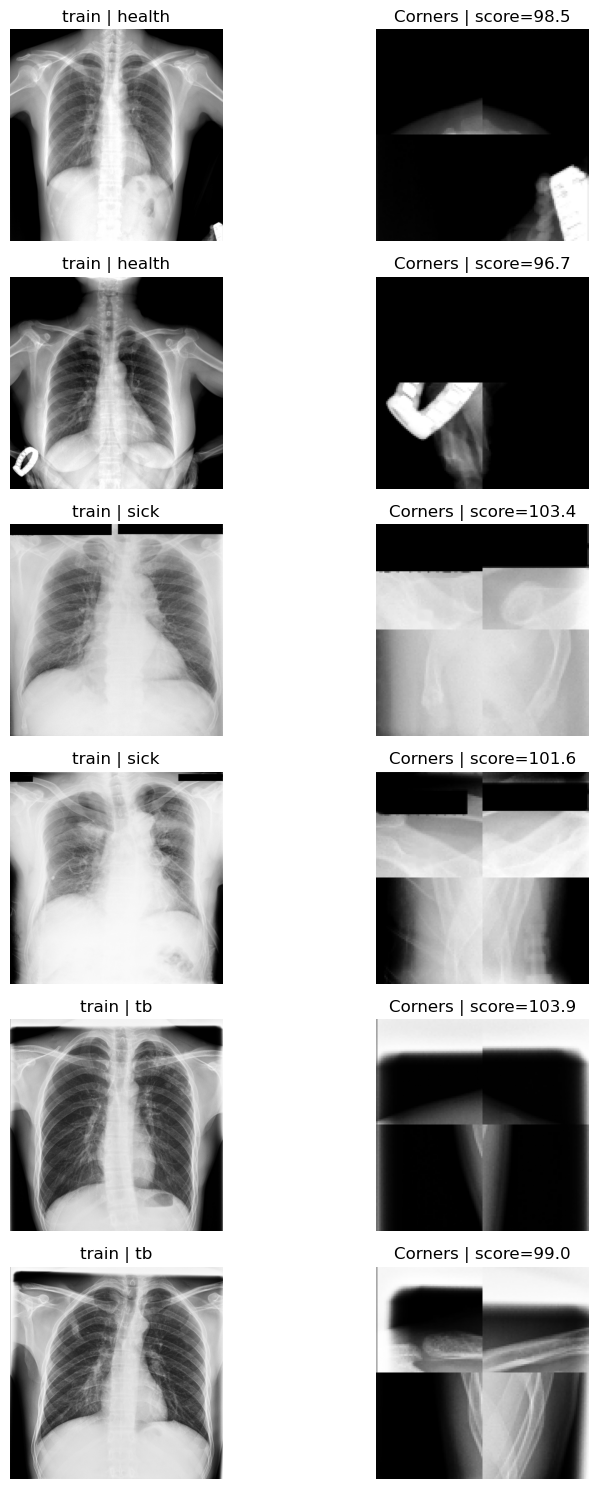

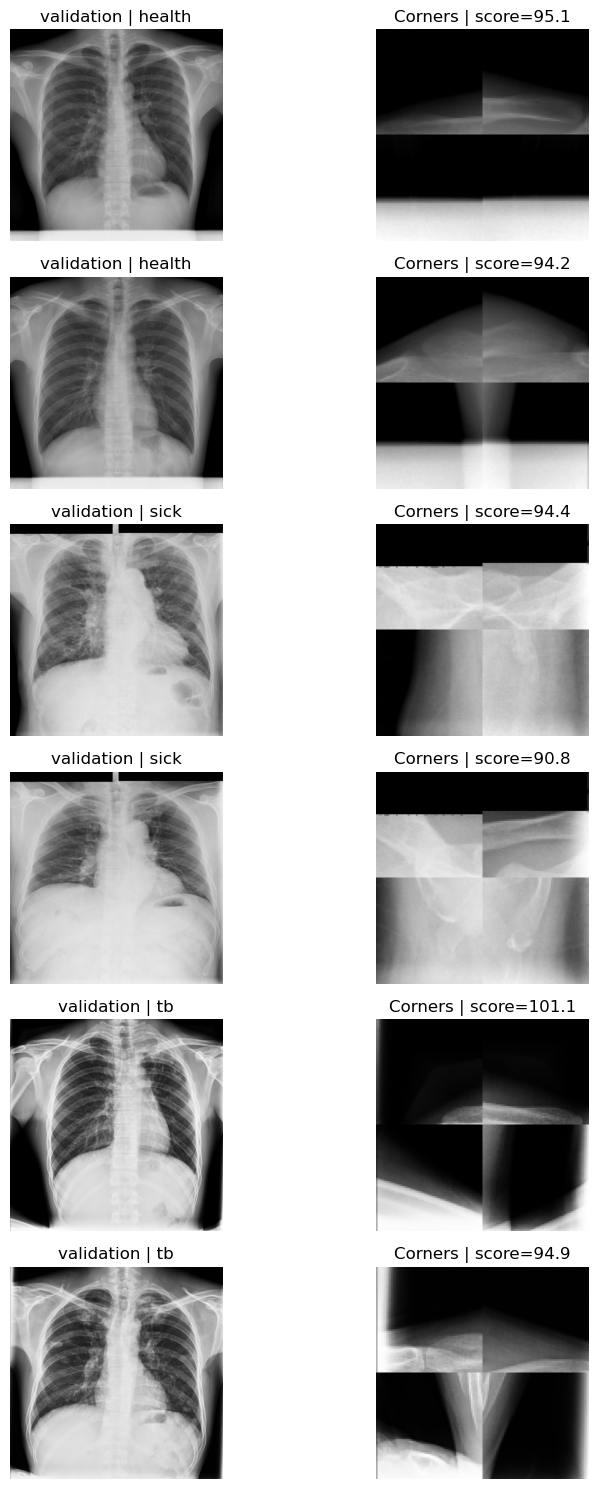

In [15]:
## 12. Visual Review of High-Scoring Corner Images

# Combine the four corners into one panel
def make_corner_panel(gray, size=64):

    top = np.hstack([gray[:size, :size],gray[:size, -size:]])

    bottom = np.hstack([gray[-size:, :size],gray[-size:, -size:]])

    return np.vstack([top, bottom])

# Show highest-scoring images from each class
def show_corner_audit(split_name, examples_per_class=2):

    subset = eda_df[eda_df["split"] == split_name]

    examples = (subset.sort_values("corner_variation",ascending=False).groupby("original_class",group_keys=False).head(examples_per_class).sort_values("original_class"))

    fig, axes = plt.subplots(len(examples),2,figsize=(9, 2.5 * len(examples)),squeeze=False)

    for row_number, (_, row) in enumerate(examples.iterrows()):

        image = load_rgb_image(row["path"])
        gray = np.asarray(image.convert("L"))

        # Show full image
        axes[row_number, 0].imshow(image)
        axes[row_number, 0].set_title(f"{split_name} | {row['original_class']}")
        axes[row_number, 0].axis("off")

        # Show four corners
        axes[row_number, 1].imshow(make_corner_panel(gray),cmap="gray")
        axes[row_number, 1].set_title(f"Corners | score={row['corner_variation']:.1f}")
        axes[row_number, 1].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir,f"corner_audit_{split_name}.png"),dpi=300,bbox_inches="tight")
    plt.show()

show_corner_audit("train")
show_corner_audit("validation")

In [16]:
## 13. Exact Duplicate Image Check

# Count how many times each image hash appears
hash_counts = eda_df["pixel_hash"].value_counts()

# Keep hashes that appear more than once
duplicate_hashes = hash_counts[hash_counts > 1].index

# Select duplicate images
duplicates = eda_df[eda_df["pixel_hash"].isin(duplicate_hashes)].sort_values("pixel_hash")

print("Exact duplicate groups:", len(duplicate_hashes))
print("Images in duplicate groups:", len(duplicates))

# Check for train-validation duplication
if not duplicates.empty:

    cross_split = duplicates.groupby("pixel_hash")["split"].nunique()

    print("Duplicate groups in both splits:",int((cross_split > 1).sum()))

    display(duplicates[["path","split","original_class","binary_label"]])


Exact duplicate groups: 126
Images in duplicate groups: 252
Duplicate groups in both splits: 38


,path,split,original_class,binary_label
5090,sick/s2456.png,train,sick,Non-TB
5123,sick/s2507.png,train,sick,Non-TB
6236,sick/s4411.png,train,sick,Non-TB
5316,sick/s2831.png,train,sick,Non-TB
4473,sick/s1450.png,train,sick,Non-TB
...,...,...,...,...
8184,sick/s3648.png,validation,sick,Non-TB
7998,sick/s2542.png,validation,sick,Non-TB
3858,sick/s0448.png,train,sick,Non-TB
4664,sick/s1765.png,train,sick,Non-TB


In [17]:
## 14. Review Cross-Split Duplicate Images
# Find duplicate groups present in both train and validation
cross_split_hashes = (duplicates.groupby("pixel_hash")["split"].nunique())

cross_split_hashes = cross_split_hashes[cross_split_hashes > 1].index

# Keep only cross-split duplicate images
cross_split_duplicates = duplicates[duplicates["pixel_hash"].isin(cross_split_hashes)].sort_values(["pixel_hash", "split"])

print("Cross-split duplicate groups:", len(cross_split_hashes))
print("Images involved:", len(cross_split_duplicates))

# Count them by split and original class
display(pd.crosstab(cross_split_duplicates["split"],cross_split_duplicates["original_class"]))

# Check whether identical images have different original classes
original_label_conflicts = (cross_split_duplicates.groupby("pixel_hash")["original_class"].nunique())

print("Groups with conflicting original classes:",int((original_label_conflicts > 1).sum()))

# Check whether identical images have different binary labels
binary_label_conflicts = (cross_split_duplicates.groupby("pixel_hash")["binary_label"].nunique())

print("Groups with conflicting binary labels:",int((binary_label_conflicts > 1).sum()))

# Display the first 20 duplicate images
display(cross_split_duplicates[["pixel_hash","path","split","original_class","binary_label"]].head(20))

# Save cross-split duplicate details
cross_split_duplicates.to_csv(os.path.join(output_dir, "cross_split_duplicates.csv"),index=False)

print("Duplicate rows saved:", len(cross_split_duplicates))

Cross-split duplicate groups: 38
Images involved: 76


original_class,sick
split,
train,38
validation,38


Groups with conflicting original classes: 0
Groups with conflicting binary labels: 0


,pixel_hash,path,split,original_class,binary_label
5927,06fd646a8da6776bcb879c5c237ed50c2581a6c4840340...,sick/s3886.png,train,sick,Non-TB
7722,06fd646a8da6776bcb879c5c237ed50c2581a6c4840340...,sick/s0751.png,validation,sick,Non-TB
5675,0d11cd0474fa07aee03692b5ffa0a335ea6594c41608b1...,sick/s3446.png,train,sick,Non-TB
7694,0d11cd0474fa07aee03692b5ffa0a335ea6594c41608b1...,sick/s0537.png,validation,sick,Non-TB
3775,0d1e07c4565b1e023193d5054b53d02190fb90f36ecf1e...,sick/s0296.png,train,sick,Non-TB
8199,0d1e07c4565b1e023193d5054b53d02190fb90f36ecf1e...,sick/s3741.png,validation,sick,Non-TB
5018,12e6519a4f3bd5945a24a4a0cf5b98d85db8292a5e6942...,sick/s2345.png,train,sick,Non-TB
7773,12e6519a4f3bd5945a24a4a0cf5b98d85db8292a5e6942...,sick/s1124.png,validation,sick,Non-TB
3629,1a87a64aee80f9b1d439d7dfc37a504ddc1941ec1eafd3...,sick/s0055.png,train,sick,Non-TB
7686,1a87a64aee80f9b1d439d7dfc37a504ddc1941ec1eafd3...,sick/s0480.png,validation,sick,Non-TB


Duplicate rows saved: 76
